# Block 4 (bonus): Linear Regression - Age vs Purchase Amount

**Goal.** Understand how a customer's **age** influences how much they spend (**Gross Amount**),
to target advertising more precisely.

**Model setup.** Independent variable **X** = age · Dependent variable **y** = `Gross Amount`.

**Question.** If a customer "gets 10 years older", how does spending change (approximately)?
Is the relationship strong, or does age barely affect spending in our store?

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# extra models for the "better solution" search
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

plt.rcParams['figure.figsize'] = (8, 5)
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the data

In [2]:
# CSV_PATH = "data/project1_df.csv"
CSV_PATH = "https://raw.githubusercontent.com/KsiuTretyakova/FinalProject_stream1_DTA/refs/heads/main/python_predict/data/project1_df.csv"

df = pd.read_csv(CSV_PATH)
print("Loaded:", df.shape[0], "rows,", df.shape[1], "columns")
df.head()

Loaded: 55000 rows, 13 columns


,CID,TID,Gender,Age Group,Purchase Date,Product Category,Discount Availed,Discount Name,Discount Amount (INR),Gross Amount,Net Amount,Purchase Method,Location
0,943146,5876328741,Female,25-45,30/08/2023 20:27:08,Electronics,Yes,FESTIVE50,64.30,725.304000,661.004000,Credit Card,Ahmedabad
1,180079,1018503182,Male,25-45,23/02/2024 09:33:46,Electronics,Yes,SEASONALOFFER21,175.19,4638.991875,4463.801875,Credit Card,Bangalore
2,337580,3814082218,Other,60 and above,06/03/2022 09:09:50,Clothing,Yes,SEASONALOFFER21,211.54,1986.372575,1774.832575,Credit Card,Delhi
3,180333,1395204173,Other,60 and above,04/11/2020 04:41:57,Sports & Fitness,No,NaN,0.00,5695.612650,5695.612650,Debit Card,Delhi
4,447553,8009390577,Male,18-25,31/05/2022 17:00:32,Sports & Fitness,Yes,WELCOME5,439.92,2292.651500,1852.731500,Credit Card,Delhi


## 3. Data-quality checks

We verify column types, find the columns we need, count missing values and duplicates,
and confirm value ranges are sensible.

In [3]:
# Check 1 - column names and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CID                    55000 non-null  int64  
 1   TID                    55000 non-null  int64  
 2   Gender                 55000 non-null  object 
 3   Age Group              55000 non-null  object 
 4   Purchase Date          55000 non-null  object 
 5   Product Category       55000 non-null  object 
 6   Discount Availed       55000 non-null  object 
 7   Discount Name          27415 non-null  object 
 8   Discount Amount (INR)  55000 non-null  float64
 9   Gross Amount           55000 non-null  float64
 10  Net Amount             55000 non-null  float64
 11  Purchase Method        55000 non-null  object 
 12  Location               55000 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 5.5+ MB


In [4]:
# Check 2 - find the gross-amount column and the age-group column
gross_col     = [c for c in df.columns if "gross" in c.strip().lower()][0]
agegroup_col  = [c for c in df.columns if "age" in c.strip().lower() and "group" in c.strip().lower()][0]
print("Gross column     ->", repr(gross_col))
print("Age-group column ->", repr(agegroup_col))
print("\nAge groups present:")
print(df[agegroup_col].value_counts())

Gross column     -> 'Gross Amount'
Age-group column -> 'Age Group'

Age groups present:
Age Group
25-45           22010
18-25           16431
45-60           11104
under 18         2771
60 and above     2684
Name: count, dtype: int64


In [5]:
# Check 3 - missing values and duplicates
print("Missing values:")
print(df[[agegroup_col, gross_col]].isna().sum())
print("\nFully duplicated rows:", df.duplicated().sum())

Missing values:
Age Group       0
Gross Amount    0
dtype: int64

Fully duplicated rows: 0


### Important data note: there is no exact age

The dataset stores **age bands** (`Age Group`), not an exact numeric age. The task asks for a numeric
`Age` and an interpretation of "+10 years", so we convert each band to its **midpoint** to obtain a
numeric age proxy:

| Age group | Numeric proxy |
|---|---|
| under 18 | 16 |
| 18-25 | 21.5 |
| 25-45 | 35 |
| 45-60 | 52.5 |
| 60 and above | 65 |

This is a reasonable assumption; the exact midpoints barely affect the result, as we will see.

In [6]:
# Map each age band to its midpoint -> numeric age proxy
midpoints = {"under 18": 16, "18-25": 21.5, "25-45": 35, "45-60": 52.5, "60 and above": 65}
df["Age"] = df[agegroup_col].map(midpoints)
print("Unmapped rows (should be 0):", df["Age"].isna().sum())

# Clean dataset for modelling
data = df[["Age", agegroup_col, gross_col]].dropna()
data = data[data[gross_col] >= 0]
print("Rows used for modelling:", len(data))

Unmapped rows (should be 0): 0
Rows used for modelling: 55000


## 4. Quick look: does spending differ by age group?

In [7]:
# Average Gross Amount per age group - the first clue about the relationship
by_group = data.groupby(agegroup_col)[gross_col].agg(["mean", "count"]).round(1)
print(by_group)

r = data["Age"].corr(data[gross_col])
print(f"\nPearson correlation (Age vs Gross Amount): r = {r:.5f}")

                mean  count
Age Group                  
18-25         2984.7  16431
25-45         3041.1  22010
45-60         2992.4  11104
60 and above  3026.0   2684
under 18      3026.5   2771

Pearson correlation (Age vs Gross Amount): r = 0.00207


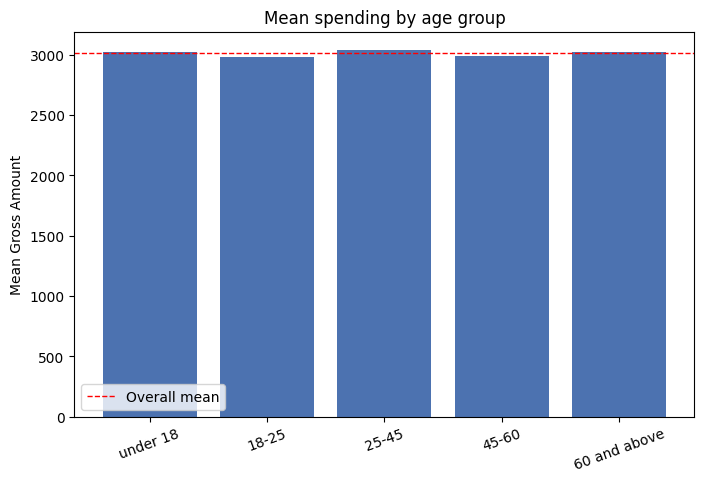

In [8]:
# Bar chart of mean spending per age group
order = ["under 18", "18-25", "25-45", "45-60", "60 and above"]
means = data.groupby(agegroup_col)[gross_col].mean().reindex(order)
plt.bar(order, means.values, color="#4C72B0")
plt.ylabel("Mean Gross Amount"); plt.title("Mean spending by age group")
plt.axhline(data[gross_col].mean(), color="red", ls="--", lw=1, label="Overall mean")
plt.legend(); plt.xticks(rotation=20); plt.show()

## 5. Linear regression (scikit-learn)

We fit `Gross Amount = intercept + coefficient * Age`. The **coefficient** tells us the change in
spending per **one extra year** of age.

In [9]:
X = data[["Age"]]
y = data[gross_col]

model = LinearRegression().fit(X, y)
slope, intercept, r2 = model.coef_[0], model.intercept_, model.score(X, y)
print(f"Coefficient (per +1 year): {slope:.4f}")
print(f"Intercept:                 {intercept:.2f}")
print(f"R^2:                       {r2:.6f}")

Coefficient (per +1 year): 0.2665
Intercept:                 3003.61
R^2:                       0.000004


## 6. Statistical detail & verification (statsmodels)

`statsmodels` adds the **p-value**, and we verify both libraries return the same coefficient.

In [10]:
ols = sm.OLS(y, sm.add_constant(X)).fit()
p_age = ols.pvalues["Age"]
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:           Gross Amount   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.2360
Date:                Tue, 30 Jun 2026   Prob (F-statistic):              0.627
Time:                        09:56:17   Log-Likelihood:            -4.8775e+05
No. Observations:               55000   AIC:                         9.755e+05
Df Residuals:                   54998   BIC:                         9.755e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3003.6059     20.556    146.118      0.0

In [11]:
# Verification: the two methods must agree
print(f"sklearn slope     : {slope:.6f}")
print(f"statsmodels slope : {ols.params['Age']:.6f}")
assert abs(slope - ols.params['Age']) < 1e-6, "Mismatch between methods!"
print("OK - methods agree. p-value for Age =", round(p_age, 4))

sklearn slope     : 0.266539
statsmodels slope : 0.266539
OK - methods agree. p-value for Age = 0.6271


## 7. Visualization: regression line over the data

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


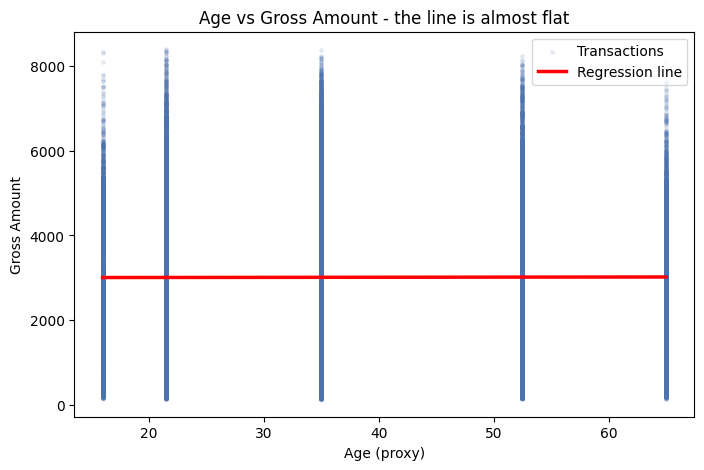

In [12]:
xs = np.linspace(data["Age"].min(), data["Age"].max(), 100).reshape(-1, 1)
plt.scatter(data["Age"], data[gross_col], alpha=0.1, s=6, color="#4C72B0", label="Transactions")
plt.plot(xs, model.predict(xs), color="red", lw=2.5, label="Regression line")
plt.xlabel("Age (proxy)"); plt.ylabel("Gross Amount")
plt.title("Age vs Gross Amount - the line is almost flat")
plt.legend(); plt.show()

## 8. Auto-generated answer

In [13]:
change_10y = slope * 10
abs_r = abs(r)
strength = ("very weak (practically none)" if abs_r < 0.1 else "weak" if abs_r < 0.3
            else "moderate" if abs_r < 0.5 else "strong")
direction = "increases" if slope > 0 else "decreases"
print("=== ANSWER ===")
print(f"- Regression coefficient (per +1 year): {slope:.3f}")
print(f"- If a customer gets 10 years older, predicted spending {direction} by only ~{abs(change_10y):.1f} INR.")
print(f"- R^2 = {r2:.6f}, correlation r = {r:.4f}  ->  relationship is {strength}.")
print(f"- p-value for Age = {p_age:.4g}  ->  age is "
      f"{'NOT statistically significant' if p_age > 0.05 else 'statistically significant'}.")

=== ANSWER ===
- Regression coefficient (per +1 year): 0.267
- If a customer gets 10 years older, predicted spending increases by only ~2.7 INR.
- R^2 = 0.000004, correlation r = 0.0021  ->  relationship is very weak (practically none).
- p-value for Age = 0.6271  ->  age is NOT statistically significant.


## 9. Search for a better model

Linear regression found almost no relationship. But maybe the link is **non-linear**, or a more
flexible model can do better? We test several models and compare them fairly on a **held-out test set**
and with **5-fold cross-validation** (metrics: R² and RMSE).

Models tested:
1. **Linear** (Age) - baseline
2. **Polynomial** degree 2 and 3 (allows a curved relationship)
3. **Decision Tree** (captures arbitrary splits by age)
4. **Random Forest** (an ensemble - usually the strongest off-the-shelf model)
5. **Linear + One-Hot age group** - gives the model a *separate parameter for every age band*
   (maximum flexibility a categorical age can offer)

As a reference, predicting the **overall mean** for everyone gives R² = 0 and RMSE = the standard
deviation of spending. A useful model must beat that.

In [14]:
baseline_rmse = y.std()
print(f"Baseline RMSE (predicting the mean for everyone): {baseline_rmse:.1f}")

# Numeric-age models share one split; the one-hot model uses the age-group column
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

results = []
def evaluate(name, est, Xfull, Xtr_, Xte_):
    est.fit(Xtr_, ytr)
    pred = est.predict(Xte_)
    test_r2  = r2_score(yte, pred)
    test_rmse = mean_squared_error(yte, pred) ** 0.5
    cv_r2 = cross_val_score(est, Xfull, y, cv=5, scoring="r2").mean()
    results.append({"Model": name, "Test R2": round(test_r2, 5),
                    "Test RMSE": round(test_rmse, 1), "CV R2 (5-fold)": round(cv_r2, 5)})

evaluate("Linear (Age)",       LinearRegression(), X, Xtr, Xte)
evaluate("Polynomial deg 2",   make_pipeline(PolynomialFeatures(2), LinearRegression()), X, Xtr, Xte)
evaluate("Polynomial deg 3",   make_pipeline(PolynomialFeatures(3), LinearRegression()), X, Xtr, Xte)
evaluate("Decision Tree",      DecisionTreeRegressor(max_depth=4, random_state=42), X, Xtr, Xte)
evaluate("Random Forest",      RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X, Xtr, Xte)

# One-hot age-group model (separate split on the categorical column)
Xg = data[[agegroup_col]]
Xg_tr, Xg_te, _, _ = train_test_split(Xg, y, test_size=0.2, random_state=42)
evaluate("Linear + One-Hot group",
         make_pipeline(OneHotEncoder(handle_unknown="ignore"), LinearRegression()), Xg, Xg_tr, Xg_te)

results_df = pd.DataFrame(results).sort_values("Test R2", ascending=False).reset_index(drop=True)
results_df

Baseline RMSE (predicting the mean for everyone): 1718.4


,Model,Test R2,Test RMSE,CV R2 (5-fold)
0,Linear (Age),-0.00011,1710.5,-0.00015
1,Polynomial deg 2,-0.00011,1710.5,-0.00017
2,Polynomial deg 3,-0.00017,1710.5,-0.00015
3,Decision Tree,-0.00058,1710.9,-0.00008
4,Linear + One-Hot group,-0.00058,1710.9,-0.00008
5,Random Forest,-0.00059,1710.9,-0.00011


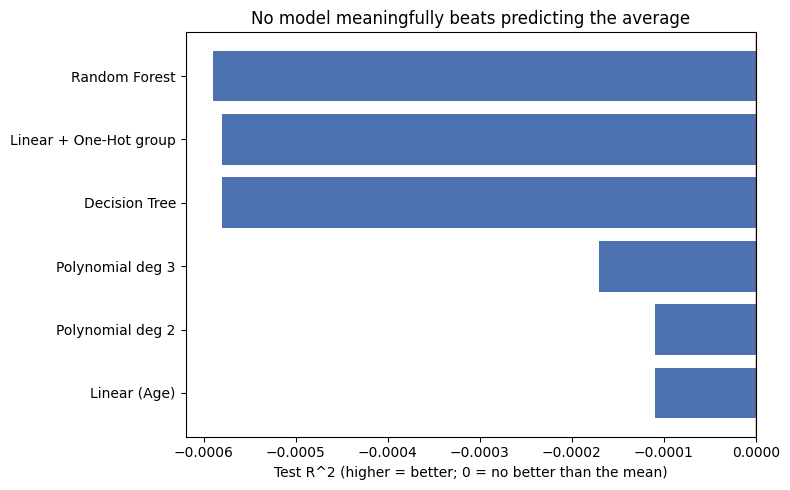

In [15]:
# Visual comparison of test R^2 across models
plt.barh(results_df["Model" if "Model" in results_df else results_df.columns[0]],
         results_df["Test R2"], color="#4C72B0")
plt.axvline(0, color="red", lw=1)
plt.xlabel("Test R^2 (higher = better; 0 = no better than the mean)")
plt.title("No model meaningfully beats predicting the average")
plt.tight_layout(); plt.show()

**Reading the table.** Every model lands at R² ≈ 0 (on both the test set and cross-validation), and
every RMSE stays essentially equal to the baseline (the standard deviation of spending). Even the
Random Forest and the one-hot model - which are free to assign any value to any age band - fail to do
better than simply guessing the average. This is strong evidence that **the weakness is in the data,
not in the model**: age carries no usable signal about how much a customer spends.

## 10. Conclusion

**The model.** The linear coefficient for age is tiny and its **R² ≈ 0**; the **p-value is well above
0.05**, so age is not a statistically significant predictor of spending. The mean Gross Amount is
practically the same (~₹3,000) in every age group.

**Answer to the director's question.** If a customer "gets 10 years older", predicted spending changes
by only a few rupees - negligible next to an average check of ~₹3,000. In practice, **age does not
drive how much a customer spends** in our store.

**Did a better model exist?** No. Polynomial regression, a decision tree, a random forest, and a
one-hot model that can treat each age band independently **all scored R² ≈ 0** and matched the
baseline RMSE. The lack of signal is a property of the data, not a limitation of linear regression -
so the simple linear model is already the right (and most interpretable) choice here.

**Business recommendation.** Allocating the marketing budget by **age is not justified**. Stronger
levers - product category, discount behaviour, purchase frequency, location - should drive targeting.
This is consistent with the dashboard finding that customer segments look near-identical across
demographics.